<a href="https://www.kaggle.com/code/matheusgabrielalves/av-ia-classificacao-iris-matheus?scriptVersionId=354483619" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Matheus Gabriel Alves da Silva
**RGM:** 11241100109

**Disciplina:** Inteligência Artificial  
**Curso:** Engenharia de Software  
**Turma:** 6B — Noite  
**Orientadores:** Prof. Fabiano Bezerra Menegidio

---

# Classificação no Iris: SVM, Árvore de Decisão, Floresta Aleatória e Boosting
Comparação **sem** e **com** GridSearchCV, usando acurácia e sensibilidade (recall).:

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


# Importando as bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Preparação dos Dados

In [3]:
df = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nProporção de classes no teste:")
print(y_test.value_counts())

Treino: (120, 4) | Teste: (30, 4)

Proporção de classes no teste:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


# Modelo 1: SVM (Support Vector Machine)

## 1. Treinamento e Otimização com GridSearchCV
O SVM é sensível à escala dos atributos, por isso usamos `StandardScaler` dentro de um `Pipeline`.

In [7]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Padronização: ajusta só no treino e aplica no teste
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# --- Cenário 1: SVM base (sem otimização) ---
svm_base = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_base.fit(X_train_sc, y_train)
pred_svm_base = svm_base.predict(X_test_sc)

acc_svm_base = accuracy_score(y_test, pred_svm_base)
rec_svm_base = recall_score(y_test, pred_svm_base, average='macro')
print(f"SVM base -> Acurácia: {acc_svm_base:.4f} | Sensibilidade (macro): {rec_svm_base:.4f}")

SVM base -> Acurácia: 0.9667 | Sensibilidade (macro): 0.9667


In [8]:
# --- Cenário 2: SVM otimizado com GridSearchCV (5 dobras) ---
param_grid_svm = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=42))]),
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train) 

melhor_svm = grid_svm.best_estimator_
pred_svm_grid = melhor_svm.predict(X_test)

acc_svm_grid = accuracy_score(y_test, pred_svm_grid)
rec_svm_grid = recall_score(y_test, pred_svm_grid, average='macro')

print("Melhores hiperparâmetros:", grid_svm.best_params_)
print(f"Melhor acurácia na validação cruzada (treino): {grid_svm.best_score_:.4f}")
print(f"SVM otimizado -> Acurácia: {acc_svm_grid:.4f} | Sensibilidade (macro): {rec_svm_grid:.4f}")

Melhores hiperparâmetros: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Melhor acurácia na validação cruzada (treino): 0.9750
SVM otimizado -> Acurácia: 0.9333 | Sensibilidade (macro): 0.9333


In [9]:
tabela_svm = pd.DataFrame({
    'Cenário': ['Sem GridSearchCV', 'Com GridSearchCV'],
    'Acurácia': [acc_svm_base, acc_svm_grid],
    'Sensibilidade (Recall macro)': [rec_svm_base, rec_svm_grid]
}).round(4)

tabela_svm

,Cenário,Acurácia,Sensibilidade (Recall macro)
0,Sem GridSearchCV,0.9667,0.9667
1,Com GridSearchCV,0.9333,0.9333


## 2. Visualizações e Avaliação

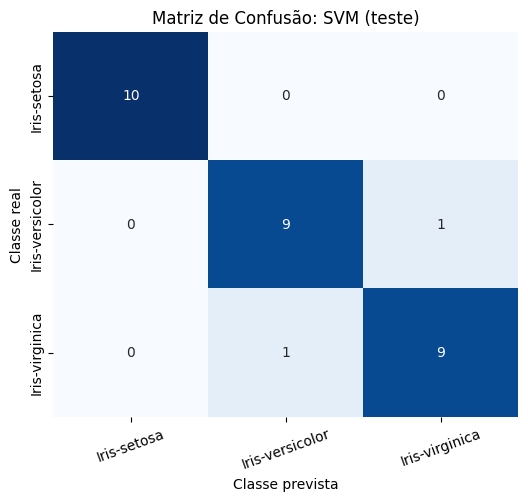

In [10]:
cm_svm = confusion_matrix(y_test, pred_svm_grid, labels=melhor_svm.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=melhor_svm.classes_, yticklabels=melhor_svm.classes_)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão: SVM (teste)")
plt.xticks(rotation=20)
plt.show()

In [11]:
print(classification_report(y_test, pred_svm_grid, digits=4))

                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     0.9000    0.9000    0.9000        10
 Iris-virginica     0.9000    0.9000    0.9000        10

       accuracy                         0.9333        30
      macro avg     0.9333    0.9333    0.9333        30
   weighted avg     0.9333    0.9333    0.9333        30



## 3. Conclusão

**Resultados (teste com 30 amostras):**

- **Sem GridSearchCV:** acurácia 0,9667 | sensibilidade (macro) 0,9667
- **Com GridSearchCV:** acurácia 0,9333 | sensibilidade (macro) 0,9333

**Análise:**

- **O GridSearchCV piorou o resultado no teste.** O Grid escolheu `kernel='linear'` e `C=0.1` porque teve a melhor acurácia na validação cruzada do treino (0,975), mas isso não garantiu ganho no teste. A diferença é de 1 amostra em 30.
- **O SVM base já foi muito bom** (0,9667), com a padronização dos dados.
- **Setosa teve 100% de acerto.** Os erros do SVM otimizado foram entre Versicolor e Virginica (1 de cada).

# Modelo 2: Árvore de Decisão

## 1. Treinamento e Otimização com GridSearchCV

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score

# --- Cenário 1: árvore base (sem otimização) ---
arvore_base = DecisionTreeClassifier(random_state=42)
arvore_base.fit(X_train, y_train)
pred_base = arvore_base.predict(X_test)

acc_base = accuracy_score(y_test, pred_base)
rec_base = recall_score(y_test, pred_base, average='macro')
print(f"Árvore base -> Acurácia: {acc_base:.4f} | Sensibilidade (macro): {rec_base:.4f}")
print("Profundidade da árvore base:", arvore_base.get_depth())

Árvore base -> Acurácia: 0.9333 | Sensibilidade (macro): 0.9333
Profundidade da árvore base: 5


In [13]:
from sklearn.model_selection import GridSearchCV

# --- Cenário 2: árvore otimizada com GridSearchCV (5 dobras) ---
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

melhor_arvore = grid.best_estimator_
pred_grid = melhor_arvore.predict(X_test)

acc_grid = accuracy_score(y_test, pred_grid)
rec_grid = recall_score(y_test, pred_grid, average='macro')

print("Melhores hiperparâmetros:", grid.best_params_)
print(f"Melhor acurácia na validação cruzada (treino): {grid.best_score_:.4f}")
print(f"Árvore otimizada -> Acurácia: {acc_grid:.4f} | Sensibilidade (macro): {rec_grid:.4f}")

Melhores hiperparâmetros: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor acurácia na validação cruzada (treino): 0.9417
Árvore otimizada -> Acurácia: 0.9333 | Sensibilidade (macro): 0.9333


In [14]:
tabela = pd.DataFrame({
    'Cenário': ['Sem GridSearchCV', 'Com GridSearchCV'],
    'Acurácia': [acc_base, acc_grid],
    'Sensibilidade (Recall macro)': [rec_base, rec_grid],
    'Profundidade': [arvore_base.get_depth(), melhor_arvore.get_depth()],
    'Nº de folhas': [arvore_base.get_n_leaves(), melhor_arvore.get_n_leaves()]
}).round(4)

tabela

,Cenário,Acurácia,Sensibilidade (Recall macro),Profundidade,Nº de folhas
0,Sem GridSearchCV,0.9333,0.9333,5,8
1,Com GridSearchCV,0.9333,0.9333,4,7


## 2. Visualizações e Avaliação

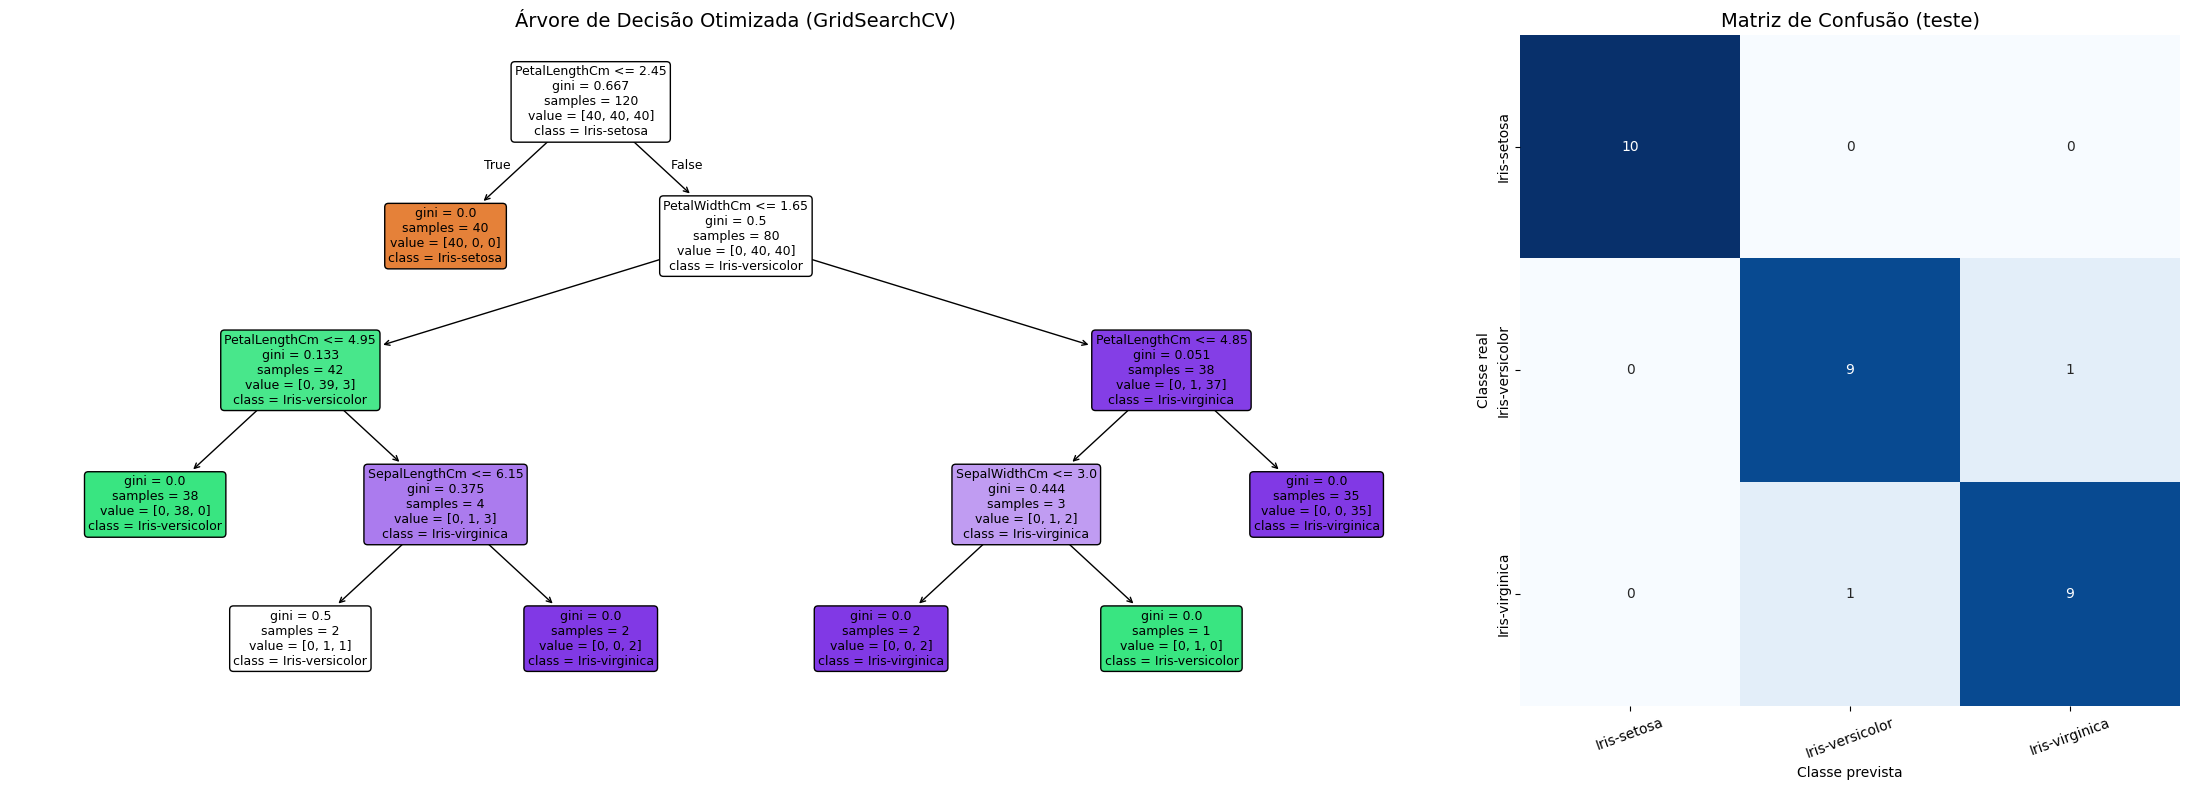

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix

classes = melhor_arvore.classes_
cm = confusion_matrix(y_test, pred_grid, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={'width_ratios': [2.2, 1]})

# 1) Estrutura da árvore otimizada
plot_tree(melhor_arvore,
          feature_names=list(X.columns),
          class_names=list(classes),
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("Árvore de Decisão Otimizada (GridSearchCV)", fontsize=14)

# 2) Matriz de confusão (conjunto de teste)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_xlabel("Classe prevista")
axes[1].set_ylabel("Classe real")
axes[1].set_title("Matriz de Confusão (teste)", fontsize=14)
plt.setp(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_grid, digits=4))

                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     0.9000    0.9000    0.9000        10
 Iris-virginica     0.9000    0.9000    0.9000        10

       accuracy                         0.9333        30
      macro avg     0.9333    0.9333    0.9333        30
   weighted avg     0.9333    0.9333    0.9333        30



In [17]:
# Importância dos atributos na árvore otimizada
importancias = pd.Series(melhor_arvore.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias.round(4))

PetalLengthCm    0.5656
PetalWidthCm     0.4112
SepalWidthCm     0.0169
SepalLengthCm    0.0063
dtype: float64


## 3. Conclusão

**Resultados (teste com 30 amostras):**

- **Sem GridSearchCV:** acurácia 0,9333 | sensibilidade (macro) 0,9333
- **Com GridSearchCV:** acurácia 0,9333 | sensibilidade (macro) 0,9333

- **O GridSearchCV não melhorou o resultado.** As duas árvores acertaram 28 das 30 amostras. A diferença é que a árvore otimizada ficou mais simples (profundidade 4, contra 5 da árvore base).
- **Setosa é a classe mais fácil.** Ela é separada logo no primeiro nó (`PetalLengthCm <= 2.45`) e foi classificada 100% certa.
- **Os erros foram entre Versicolor e Virginica.** Essas duas espécies têm medidas parecidas, então a árvore confunde algumas amostras (1 de cada).
- **Limitar a profundidade (`max_depth`) evita overfitting.** Sem limite, a árvore cresce até decorar os dados de treino e generaliza pior. Aqui a diferença foi pequena porque o Iris é um dataset simples.

# Modelo 3: Floresta Aleatória

## 1. Treinamento e Otimização com GridSearchCV

In [18]:
from sklearn.ensemble import RandomForestClassifier

# --- Cenário 1: floresta base (sem otimização) ---
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
pred_rf_base = rf_base.predict(X_test)

acc_rf_base = accuracy_score(y_test, pred_rf_base)
rec_rf_base = recall_score(y_test, pred_rf_base, average='macro')
print(f"Floresta base -> Acurácia: {acc_rf_base:.4f} | Sensibilidade (macro): {rec_rf_base:.4f}")

Floresta base -> Acurácia: 0.9000 | Sensibilidade (macro): 0.9000


In [19]:
# --- Cenário 2: floresta otimizada com GridSearchCV (5 dobras) ---
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

melhor_rf = grid_rf.best_estimator_
pred_rf_grid = melhor_rf.predict(X_test)

acc_rf_grid = accuracy_score(y_test, pred_rf_grid)
rec_rf_grid = recall_score(y_test, pred_rf_grid, average='macro')

print("Melhores hiperparâmetros:", grid_rf.best_params_)
print(f"Melhor acurácia na validação cruzada (treino): {grid_rf.best_score_:.4f}")
print(f"Floresta otimizada -> Acurácia: {acc_rf_grid:.4f} | Sensibilidade (macro): {rec_rf_grid:.4f}")

Melhores hiperparâmetros: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Melhor acurácia na validação cruzada (treino): 0.9583
Floresta otimizada -> Acurácia: 0.9667 | Sensibilidade (macro): 0.9667


In [20]:
tabela_rf = pd.DataFrame({
    'Cenário': ['Sem GridSearchCV', 'Com GridSearchCV'],
    'Acurácia': [acc_rf_base, acc_rf_grid],
    'Sensibilidade (Recall macro)': [rec_rf_base, rec_rf_grid]
}).round(4)

tabela_rf

,Cenário,Acurácia,Sensibilidade (Recall macro)
0,Sem GridSearchCV,0.9000,0.9000
1,Com GridSearchCV,0.9667,0.9667


## 2. Visualizações e Avaliação

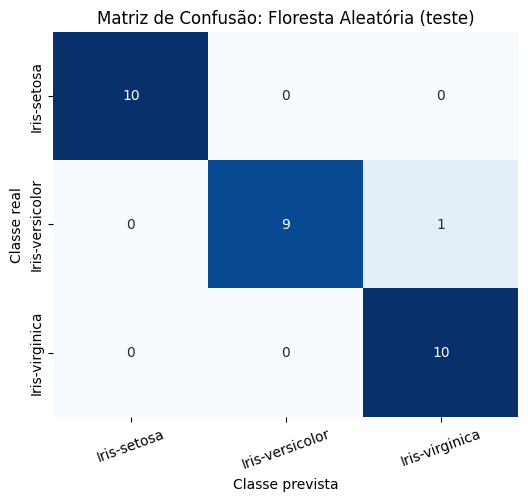

In [21]:
cm_rf = confusion_matrix(y_test, pred_rf_grid, labels=melhor_rf.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=melhor_rf.classes_, yticklabels=melhor_rf.classes_)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão: Floresta Aleatória (teste)")
plt.xticks(rotation=20)
plt.show()

In [22]:
print(classification_report(y_test, pred_rf_grid, digits=4))

                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     1.0000    0.9000    0.9474        10
 Iris-virginica     0.9091    1.0000    0.9524        10

       accuracy                         0.9667        30
      macro avg     0.9697    0.9667    0.9666        30
   weighted avg     0.9697    0.9667    0.9666        30



In [23]:
importancias_rf = pd.Series(melhor_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias_rf.round(4))

PetalLengthCm    0.4442
PetalWidthCm     0.4355
SepalLengthCm    0.1143
SepalWidthCm     0.0060
dtype: float64


## 3. Conclusão

**Resultados (teste com 30 amostras):**

- **Sem GridSearchCV:** acurácia 0,9000 | sensibilidade (macro) 0,9000
- **Com GridSearchCV:** acurácia 0,9667 | sensibilidade (macro) 0,9667

**Análise:**

- **O GridSearchCV melhorou o resultado.** A acurácia e a sensibilidade subiram de 0,9000 para 0,9667 (de 27 para 29 acertos em 30).
- **A floresta base foi pior que a árvore base** (0,9000 contra 0,9333), mas a otimizada foi melhor que a árvore otimizada (0,9667 contra 0,9333).
- **Setosa continua sendo a mais fácil**, com 100% de acerto. O único erro foi entre Versicolor e Virginica.
- **Os atributos da pétala são os mais importantes**, como na árvore.

# Modelo 4: Boosting (Gradient Boosting)

## 1. Treinamento e Otimização com GridSearchCV

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# --- Cenário 1: boosting base (sem otimização) ---
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train, y_train)
pred_gb_base = gb_base.predict(X_test)

acc_gb_base = accuracy_score(y_test, pred_gb_base)
rec_gb_base = recall_score(y_test, pred_gb_base, average='macro')
print(f"Boosting base -> Acurácia: {acc_gb_base:.4f} | Sensibilidade (macro): {rec_gb_base:.4f}")

Boosting base -> Acurácia: 0.9667 | Sensibilidade (macro): 0.9667


In [25]:
# --- Cenário 2: boosting otimizado com GridSearchCV (5 dobras) ---
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [1, 2, 3],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)

melhor_gb = grid_gb.best_estimator_
pred_gb_grid = melhor_gb.predict(X_test)

acc_gb_grid = accuracy_score(y_test, pred_gb_grid)
rec_gb_grid = recall_score(y_test, pred_gb_grid, average='macro')

print("Melhores hiperparâmetros:", grid_gb.best_params_)
print(f"Melhor acurácia na validação cruzada (treino): {grid_gb.best_score_:.4f}")
print(f"Boosting otimizado -> Acurácia: {acc_gb_grid:.4f} | Sensibilidade (macro): {rec_gb_grid:.4f}")

Melhores hiperparâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Melhor acurácia na validação cruzada (treino): 0.9667
Boosting otimizado -> Acurácia: 0.9667 | Sensibilidade (macro): 0.9667


In [26]:
tabela_gb = pd.DataFrame({
    'Cenário': ['Sem GridSearchCV', 'Com GridSearchCV'],
    'Acurácia': [acc_gb_base, acc_gb_grid],
    'Sensibilidade (Recall macro)': [rec_gb_base, rec_gb_grid]
}).round(4)

tabela_gb

,Cenário,Acurácia,Sensibilidade (Recall macro)
0,Sem GridSearchCV,0.9667,0.9667
1,Com GridSearchCV,0.9667,0.9667


## 2. Visualizações e Avaliação

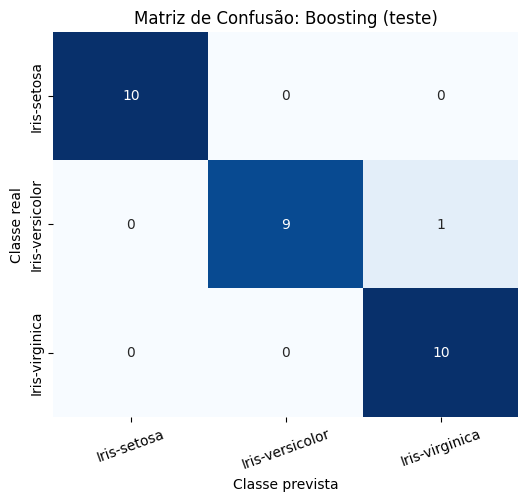

In [27]:
cm_gb = confusion_matrix(y_test, pred_gb_grid, labels=melhor_gb.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=melhor_gb.classes_, yticklabels=melhor_gb.classes_)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão: Boosting (teste)")
plt.xticks(rotation=20)
plt.show()

In [28]:
print(classification_report(y_test, pred_gb_grid, digits=4))

                 precision    recall  f1-score   support

    Iris-setosa     1.0000    1.0000    1.0000        10
Iris-versicolor     1.0000    0.9000    0.9474        10
 Iris-virginica     0.9091    1.0000    0.9524        10

       accuracy                         0.9667        30
      macro avg     0.9697    0.9667    0.9666        30
   weighted avg     0.9697    0.9667    0.9666        30



In [29]:
# Importância dos atributos no boosting otimizado
importancias_gb = pd.Series(melhor_gb.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias_gb.round(4))

PetalWidthCm     0.6356
PetalLengthCm    0.3457
SepalWidthCm     0.0151
SepalLengthCm    0.0036
dtype: float64


## 3. Conclusão

**Resultados (teste com 30 amostras):**

- **Sem GridSearchCV:** acurácia 0,9667 | sensibilidade (macro) 0,9667
- **Com GridSearchCV:** acurácia 0,9667 | sensibilidade (macro) 0,9667

**Análise:**

- **O GridSearchCV não alterou o resultado.** Os melhores hiperparâmetros encontrados (`learning_rate=0.1`, `max_depth=3`, `n_estimators=100`, `subsample=1.0`) são os mesmos valores padrão do modelo, por isso o resultado é idêntico.
- **O boosting base já foi o melhor modelo base** (0,9667, contra 0,9333 da árvore e 0,9000 da floresta).
- **Setosa teve 100% de acerto.** O único erro foi uma Versicolor classificada como Virginica.
- **Os atributos da pétala dominam**, com destaque para `PetalWidthCm` (0,65), seguido de `PetalLengthCm` (0,33).

# Comparação Final dos Modelos

In [30]:
comparacao = pd.DataFrame({
    'Modelo': ['SVM', 'Árvore de Decisão', 'Floresta Aleatória', 'Boosting'],
    'Acurácia (sem Grid)': [acc_svm_base, acc_base, acc_rf_base, acc_gb_base],
    'Acurácia (com Grid)': [acc_svm_grid, acc_grid, acc_rf_grid, acc_gb_grid],
    'Sensibilidade (sem Grid)': [rec_svm_base, rec_base, rec_rf_base, rec_gb_base],
    'Sensibilidade (com Grid)': [rec_svm_grid, rec_grid, rec_rf_grid, rec_gb_grid],
}).round(4)

comparacao

,Modelo,Acurácia (sem Grid),Acurácia (com Grid),Sensibilidade (sem Grid),Sensibilidade (com Grid)
0,SVM,0.9667,0.9333,0.9667,0.9333
1,Árvore de Decisão,0.9333,0.9333,0.9333,0.9333
2,Floresta Aleatória,0.9000,0.9667,0.9000,0.9667
3,Boosting,0.9667,0.9667,0.9667,0.9667


In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Checagem de robustez: validação cruzada de 5 dobras no dataset inteiro
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
modelos_cv = {
    'SVM': melhor_svm,
    'Árvore de Decisão': melhor_arvore,
    'Floresta Aleatória': melhor_rf,
    'Boosting': melhor_gb,
}

resultados_cv = []
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy')
    resultados_cv.append({'Modelo': nome, 'Acurácia média (CV)': scores.mean(), 'Desvio padrão': scores.std()})

pd.DataFrame(resultados_cv).round(4)

,Modelo,Acurácia média (CV),Desvio padrão
0,SVM,0.9533,0.0340
1,Árvore de Decisão,0.9533,0.0340
2,Floresta Aleatória,0.9600,0.0389
3,Boosting,0.9533,0.0340


# Conclusão Geral

**Qual modelo apresentou melhor sensibilidade e acurácia?**

- No conjunto de teste, o **Boosting** foi o melhor: acurácia e sensibilidade de 0,9667 tanto sem quanto com GridSearchCV.
- A **Floresta Aleatória** também chegou a 0,9667, mas só com GridSearchCV (sem Grid ficou em 0,9000).
- O **SVM** foi bom sem Grid (0,9667), mas caiu para 0,9333 com Grid. A **Árvore de Decisão** ficou em 0,9333 nos dois cenários.
- 
**Efeito do GridSearchCV:**

- Ajudou claramente a Floresta Aleatória.
- Não alterou Árvore e Boosting.
- Piorou o SVM no teste, porque o Grid escolhe pela validação cruzada do treino, que não garante ganho no teste.

**Sensibilidade e acurácia:** os valores são iguais em todos os modelos porque as 3 classes são balanceadas.